In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys

sys.path.append(os.path.dirname(os.path.abspath('.')))
from utils.load_api_keys import load_api_tokens

#load all tokens
api_keys = load_api_tokens()
HF_TOKEN = api_keys["HF_TOKEN"]
PERSIST_DIR = api_keys["PERSIST_DIR"]
OPENAI_API_KEY = api_keys["OPENAI_API_KEY"]
GROQ_API_KEY = api_keys["GROQ_API_KEY"]
LANGCHAIN_API_KEY = api_keys["LANGCHAIN_API_KEY"]
LANGCHAIN_TRACING_V2 = api_keys["LANGCHAIN_TRACING_V2"]
LANGCHAIN_PROJECT = api_keys["LANGCHAIN_PROJECT"]
LANGCHAIN_ENDPOINT = api_keys["LANGCHAIN_ENDPOINT"]

In [10]:
from typing import Literal, Sequence, Annotated, Dict
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.graph import END, StateGraph, START, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_chroma import Chroma
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from IPython.display import Image, display, Markdown
from langgraph.checkpoint.memory import MemorySaver
from langchain.tools.retriever import create_retriever_tool
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate



In [3]:
embeddings = OpenAIEmbeddings(model="text-embedding-ada-002", api_key=OPENAI_API_KEY)
#groqapi
llm=ChatGroq(model_name="llama-3.3-70b-versatile")
#openaiapi
#llm = ChatOpenAI(model="gpt-3.5-turbo")

In [4]:
llm.invoke

<bound method BaseChatModel.invoke of ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x00000233644AA070>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000233645BBEB0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))>

In [7]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    source: str
    department: str

PROGRAMS = ["IS","CS","GENED","BS","BA","Courses","Minors","AddMajors"]
class RouteQuery(BaseModel):
    department: str = Field(description=f"Most relevant programs from the list: {PROGRAMS }.")

In [9]:
# Data model Example
class RouteQuery_example(BaseModel):
   """Route a user query to the most relevant datasource."""
   datasource: Literal["IS","CS","GENED","BIO","BA","Courses","Minors"] = Field(
       description="Given a user question choose to route it to web search or a vectorstore.",
   )
# LLM with function call
structured_llm_router = llm.with_structured_output(RouteQuery_example)
# Prompt
system = """You are an expert at routing a user question to different vectorstores or web search.
The IS vectorstore contains documents related to Information Systems Concentration, advising documents, 
concentration FAQs, requirements and sample curriculum.
The CS vectorstore contains documents related to Computer Science Concentration, advising documents, requirements and sample curriculum.
The Course vectorstore contains documents related to all courses offered by CMU. It contains the course number, name,
prerequisites, offerings, long description maximum and minimum units etc.
The Minors vectorstore contains documents related to minor course requirements such as minor name, advisor name, required courses, etc
Use the corresponding vectorstore for questions on these topics. 
Otherwise, use web-search."""
route_prompt = ChatPromptTemplate.from_messages(
   [
       ("system", system),
       ("human", "{question}"),
   ]
)

question_router = route_prompt | structured_llm_router
print(question_router.invoke({"question": "what is 67-373"}))

datasource='Courses'


In [ ]:
#Retriever to retriever tool for IS Major details
'''retriever_tool_major = create_retriever_tool(
    ISMajor_retriever,
    "retriver_vector_db_major",
    """Search and return information about CMU Qatar Information Systems program including
    - IS_Concentrations
    - CMUQ_IS_Advising_Document
    - IS_Requirements
    - IS_Concentration_FAQ
    You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to 
    the CMUQ knowledge base in the retriever.
    """
)
retriever_tool_major
#Retriever to retriever tool for IS Course details
retriever_tool_course = StructuredTool.from_function(
    func = course_tool_with_code_filter,
    name = "retriver_vector_db_course",
    description = """Search and return information about CMU Qatar courses. Provide details when a course code is given (e.g., 67272, 67-272, or 67 272).
    Use this 'retriever_tool' only when the query specifically relates to CMUQ courses."""
)
retriever_tool_course
tools = [retriever_tool_major,retriever_tool_course]
tools
'''

In [11]:
PROGRAMS

['IS', 'CS', 'GENED', 'BS', 'BA', 'Courses', 'Minors', 'AddMajors']

In [33]:
#workflow
#docstring is very important as the llm will read the docstring and will able to understand what this node is going to do.
def agent(state):
    """
    
    Classifies the user message for the target program using an LLM.
    """
    print("***********CALL AGENT**************")
    
    messages = state['messages']
    model = llm
    # Prepare prompt for classification
    prompt_template = ChatPromptTemplate.from_messages([
        SystemMessage(
            content=f"""You are an expert at routing a user question to different vectorstores or web search.
                    Analyze the user's message to determine its the most relevant program's vectorstores.
                  The available programs are: {', '.join(PROGRAMS)}  
                The IS vectorstore contains documents related to Information Systems Concentration, advising documents, 
                concentration FAQs, requirements and sample curriculum.
                The BS vectorstore contains documents related to Biological Sciences Concentration, advising documents, 
                requirements and sample curriculum.
                The BA vectorstore contains documents related to Business Administration Concentration, advising documents, 
                requirements and sample curriculum.
                The CS vectorstore contains documents related to Computer Science Concentration, advising documents, 
                requirements and sample curriculum.
                The GENED vectorstore contains documents related to General Education Concentration, advising documents, 
                requirements and sample curriculum.
                The Courses vectorstore contains documents related to all courses offered by CMU. 
                It contains the course number (for ex: 67-373, or 67373 or 67 373), course name,
                prerequisites, offerings, long description maximum and minimum units etc.
                The Minors vectorstore contains documents related to minor course requirements such as minor name, advisor name, required courses, etc
                The AddMajors vectorstore contains documents related to additional major details of the course. 
                Use the corresponding vectorstore for questions on these topics. 
                Otherwise, use web-search.
                Respond ONLY with the structured JSON output format."""
        ),
        HumanMessage(content=f"User Query: {messages}")
    ])
    #model = model.bind_tools(tools)
    classifier_chain = prompt_template | model.with_structured_output(RouteQuery)
    try:
        result: RouteQuery = classifier_chain.invoke({}) # Pass empty dict as input seems required now
        print(f"  Classification Result: program='{result.department}'")
        return {
            "department": result.department
            }
    except Exception as e:
        print(f"  Error during classification: {e}")
        return {
            "department": "web_search",
            "error": f"Classification failed: {e}"
            }

import re

def extract_course_code(query: str) -> str:
    match = re.search(r"(\d{2,3})[- ]?(\d{3})", query)
    if match:
        return f"{match.group(1)}-{match.group(2)}"
    return None

def retrieve_context_node(state: AgentState) -> Dict[str, str]:
    """
    Retrieves relevant context from the vector store based on the query and department.
    """
    print("--- Retrieving Context ---")
    messages = state["messages"]
    department = state["department"]
    course_code = ""
   
    # Initialize embedding model and vector store access
    if department == "IS":
        vector_store = Chroma(persist_directory=PERSIST_DIR+"IS/MajorData", embedding_function=embeddings)
    
    elif department == "CS":
        vector_store = Chroma(persist_directory=PERSIST_DIR+"CS/MajorData", embedding_function=embeddings)

    elif department == "BS":
        vector_store = Chroma(persist_directory=PERSIST_DIR+"BS/MajorData", embedding_function=embeddings)

    elif department == "BA":
        vector_store = Chroma(persist_directory=PERSIST_DIR+"BA/MajorData", embedding_function=embeddings)

    elif department == "GENED":
        vector_store = Chroma(persist_directory=PERSIST_DIR+"GENED/MajorData", embedding_function=embeddings)
    
    elif department == "Courses":
        vector_store = Chroma(persist_directory=PERSIST_DIR+"/Courses", embedding_function=embeddings)
        course_code = extract_course_code(messages[0].content)
        print("course",course_code)
    
    elif department == "Minors":
        vector_store = Chroma(persist_directory=PERSIST_DIR+"/MinorData", embedding_function=embeddings)
    elif department == "AddMajors":
        vector_store = Chroma(persist_directory=PERSIST_DIR+"/AddMajorData", embedding_function=embeddings)
    elif department == "web-search":
        print("  Skipping retrieval: Department unknown or not applicable.")
        return {"context": "", "error": "Cannot retrieve context without a valid department."}
    print("course",course_code)
    if course_code:
        print(course_code)
        retriever = vector_store.as_retriever(
            search_type="similarity",
            search_kwargs={
            "k":5,
                "filter": {
                    "source": course_code
                }
            }
            
        )
    else:
        retriever = vector_store.as_retriever(
            search_type="similarity",
            search_kwargs={
                'k': 5, # Retrieve top 5 relevant docs
                
                }
        )

    try:
        print(retriever)
        retrieved_docs = retriever.invoke(messages[0].content)
        print("retrieved docs :", type(retrieved_docs))
        if retrieved_docs:
            context = "\n\n---\n\n".join([doc.page_content for doc in retrieved_docs])
            print(f"  Retrieved {len(retrieved_docs)} documents for department '{department}'.")
            # print(f"  Context Snippet: {context[:200]}...") # Optional: log snippet
            return {'messages':[context]}
        else:
            print("  No relevant documents found in vector store for this department.")
            return {"context": "", "error": "No relevant context found."}
    except Exception as e:
        print(f"  Error during context retrieval: {e}")
        return {"context": "", "error": f"Retrieval failed: {e}"}


#create a functionality for grading the document
from pydantic import BaseModel, Field
def grade_documents(state) -> Literal['generate','rewrite']:
    """
    Determine whether the retrieved documents are relevant to the question.

    Args:
        state(messages): the current state

    Returns:
        str: A decision for whether the documents are relevant or not.
    """
    print("********************Check Relevance***************")

    #Data model
    class grade(BaseModel):
        """ Binary score for relevance check"""
        binary_score: str = Field(description="Relevance Score 'yes' or 'no'")

    model = llm
    llm_with_tool = model.with_structured_output(grade)

    prompt = PromptTemplate(
        template="""
        You are a grader assessing relevance of a retrieved document to a user question.\n
        Here is the retrieved document : \n\n{context} \n\n
        Here is the user query: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
        """,
        input_variables=['context','question'],
    )

    #chain
    chain = prompt | llm_with_tool

    messages = state['messages']
    last_message = messages[-1]

    question = messages[0].content
    print(question)
    docs = last_message.content
    print(docs)

    scored_result = chain.invoke({'question':question,'context':docs})
    score = scored_result.binary_score

    if score=="yes":
        print("Docs are relevent")
        return 'generate'
    else:
        print("Docs are not relevant")
        return 'rewrite'

In [34]:
#generate function
from langchain_core.output_parsers import StrOutputParser
def generate(state):

    """
    Generates a response using RAG based on the query and retrieved context.

    Args:
        state(messages): the current state
    Returns:
        dict: the updated message
    """

    print("***********Generate*************")
    messages = state['messages']
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    prompt = PromptTemplate(
        template="""You are a helpful assistant for CMU Qatar students.
        Use the following context to answer the question about the corresponding program requirements, courses, concentrations, curriculum, or policies.

        Context: {context}

        Question: {question}
        Guidelines for your response:
        1. Base your answer STRICTLY on the provided context
        2. If the context contains specific course numbers, requirements, or policies, include them
        3. If the context is insufficient, acknowledge this and suggest where to find more information
        4. Keep the response focused on CMU Qatar program specifics
        5. Format your response in a clear, structured manner
        
        
        Answer:""",
        input_variables=["context", "question"]
    )

    model = llm
    rag_chain = prompt | model | StrOutputParser()

    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [35]:
def rewrite(state:AgentState):
    """
    Transform the query to produce a better question.
    
    Args:
        state(messages): the current state

    Returns:
        dict: the updated state with re-phrased question

    """
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    message_content = f"""Look at the input and try to reason about the underlying semantic intent / meaning related to CMU Qatar Information Systems program.
                    Here is the initial question: {question}
                    Reformulate this as a clearer question about cmu courses, concentrations, curriculum, advising, or academic policies: """
    message = [HumanMessage(content=message_content)]

    model = llm

    response = model.invoke(message)
    return {"messages": [response]}

In [36]:
def build_agent_graph() -> StateGraph:
    """Builds the LangGraph agent."""
    workflow=StateGraph(AgentState)
    #add nodes
    workflow.add_node("agent", agent)
    #retrieve = ToolNode([retriever_tool_major,retriever_tool_course])
    workflow.add_node("retrieve", retrieve_context_node)
    workflow.add_node("generate", generate)
    workflow.add_node("rewrite", rewrite)

    workflow.add_edge(START, "agent")
    workflow.add_edge("agent", "retrieve")
    workflow.add_conditional_edges("retrieve",grade_documents,)
    workflow.add_edge("generate", END)
    workflow.add_edge("rewrite","agent")

    #memory = MemorySaver()
    #graph = workflow.compile(checkpointer=memory)
    graph = workflow.compile()
    return graph

In [ ]:
#building the stategraph
'''
workflow=StateGraph(AgentState)
workflow.add_node("agent", agent)
#retrieve = ToolNode([retriever_tool_major,retriever_tool_course])
workflow.add_node("retrieve", retrieve_context_node)
workflow.add_node("generate", generate)
workflow.add_node("rewrite", rewrite)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition, {"tools":"retrieve",END:END},)
workflow.add_conditional_edges("retrieve",grade_documents,)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite","agent")

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
#graph = workflow.compile()'''

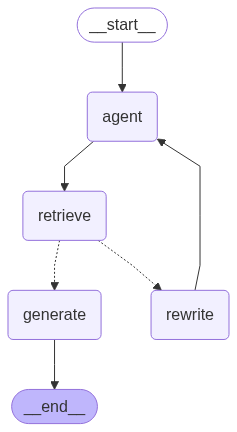

In [37]:
graph = build_agent_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
test_queries = [
   "what is 67373",
   "what are the gened requirements for IS?",
   "what are the prerequisites for 67-272?",
   "what are the minor requirements of CS",
]

In [18]:
print("\n--- Testing Agent ---")
for query in test_queries:
   print(f"\nInput Query: {query}")
   messages = HumanMessage(content=query)
   try:
   # Invoke the graph
   # The config argument is optional but useful for stateful execution if needed
      config = {"configurable": {"thread_id": "user_123"}} # Example config
      final_state = graph.invoke({"messages":[messages]}, config=config)

      for message in final_state['messages']:
            message.pretty_print()
      if final_state.get('error'):
            print(f"Error encountered: {final_state.get('error')}")

   except Exception as e:
      print(f"ERROR running agent graph for query '{query}': {e}")
      import traceback
      traceback.print_exc() 
print("\n--- Agent Testing Complete ---")


--- Testing Agent ---

Input Query: what is 67373
***********CALL AGENT**************
  Classification Result: program='Courses'
--- Retrieving Context ---
course 67-373
course 67-373
67-373
tags=['Chroma', 'OpenAIEmbeddings'] vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x000002336473EC40> search_kwargs={'k': 5, 'filter': {'source': '67-373'}}
retrieved docs : <class 'list'>
  Retrieved 5 documents for department 'Courses'.
********************Check Relevance***************
what is 67373
{"code": "67-373", "name": "Information Systems Consulting Project", "base_name": "Information Systems Consulting Project", "units": 12, "min_units": 12, "max_units": 12, "short_name": "IS CONSULTING PROJ", "is_topic": false, "prereqs": {"text": "67-272 [] at least D", "req_obj": {"id": 7946985, "screen_name": "udrfmpkl34h8x22", "original_min_units": null, "min_units": null, "is_shared": false, "is_uni_req": false, "is_concentration": false, "default_concentration": false, "choices": {

In [162]:
#config = {"configurable":{"thread_id":16}}
messages = HumanMessage(content="What is 67-373?")
#messages = graph.invoke({"messages":[messages]},config=config,)
messages = graph.invoke({"messages":[messages]})
for message in messages['messages']:
    message.pretty_print()

***********CALL AGENT**************
[HumanMessage(content='What is 67-373?', additional_kwargs={}, response_metadata={}, id='d84b7286-a091-4301-bd7b-ebf4b7ed4523')]
[HumanMessage(content='What is 67-373?', additional_kwargs={}, response_metadata={}, id='d84b7286-a091-4301-bd7b-ebf4b7ed4523')]
  Classification Result: program='Courses'
--- Retrieving Context ---
course 67-373
course 67-373
67-373
tags=['Chroma', 'OpenAIEmbeddings'] vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x0000024582560070> search_kwargs={'k': 5, 'filter': {'source': '67-373'}}
retrieved docs : <class 'list'>
  Retrieved 5 documents for department 'Courses'.
********************Check Relevance***************
What is 67-373?
{"code": "67-373", "name": "Information Systems Consulting Project", "base_name": "Information Systems Consulting Project", "units": 12, "min_units": 12, "max_units": 12, "short_name": "IS CONSULTING PROJ", "is_topic": false, "prereqs": {"text": "67-272 [] at least D", "req_obj": 

In [19]:
#config = {"configurable":{"thread_id":16}}
message = HumanMessage(content="What are the concentration options in IS?")
messages = graph.invoke({"messages":[message]},config=config,)
for message in messages['messages']:
    message.pretty_print()

***********CALL AGENT**************
  Classification Result: program='IS'
--- Retrieving Context ---
course 
tags=['Chroma', 'OpenAIEmbeddings'] vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x00000233647FE040> search_kwargs={'k': 5}
retrieved docs : <class 'list'>
  Retrieved 5 documents for department 'IS'.
********************Check Relevance***************
What are the concentration options in IS?
{"Subheading": "Concentrations", "Content": "As part of the BSc. in Information Systems, students must complete a concentration, which provides specialized knowledge in a particular area of study.What is a concentration?\u25cf A concentration consists of:  \u25cb Three advanced 9-unit courses (27 units).  \u25cb One summative 9-unit project course or an equivalent advised research experience.\u25cf Students may also substitute an approved minor or second major for a concentration.\u25cf Typically, concentrations are completed during the 3rd and 4th years of study.The departme

In [20]:
messages['messages'][-1].content

'**Concentration Options in IS at CMU Qatar**\n\nAccording to the provided context, CMU Qatar offers the following concentrations in the BSc. in Information Systems program:\n\n1. **Data Science**\n2. **Digitalization**\n3. **Information Security and Privacy**\n\nThese concentrations provide specialized knowledge in a particular area of study and consist of:\n* Three advanced 9-unit courses (27 units)\n* One summative 9-unit project course or an equivalent advised research experience\n\nAlternatively, students may substitute an approved minor or second major for a concentration. Typically, concentrations are completed during the 3rd and 4th years of study. For more information on specific course fulfillments, students can refer to the "IS Concentrations: Information and Guidelines" document.'

In [30]:
res = graph.invoke({"messages":"what are the gened requirements for IS?"},config=config,)
res['messages'][-1].pretty_print()

***********CALL AGENT**************
  Classification Result: program='GENED'
--- Retrieving Context ---
course 
tags=['Chroma', 'OpenAIEmbeddings'] vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x00000233018067C0> search_kwargs={'k': 5}
retrieved docs : <class 'list'>
  Retrieved 5 documents for department 'GENED'.
********************Check Relevance***************
what are the gened requirements for IS?
{"Section": "Special Seminars", "Requirements": {"0": {"Category": "Grand Challenge Seminar", "Description": "First-year students take a seminar on real, complex global problems (e.g., sustainability, equity) taught by multidisciplinary faculty teams.", "Units Required": "9 units", "Timeline": "Required in Year 1"}, "1": {"Category": "Perspectives on Justice and Injustice", "Description": "Courses examine inequalities that lead to or result from injustice, exploring which inequalities we are ethically obligated to combat and how to do so.", "Units Required": "9 units", "T

In [38]:
def ask_advisor_bot(message,history):
    # Create the input format expected by your chatbot
    messages =[HumanMessage(content=message)]
    print(messages)
    
    # Get the final response
    final_response = None
    try:
        config = {"configurable": {"thread_id": "user_1234"}} # Example config
        final_state = graph.invoke({"messages":messages}, config=config)
        final_response = final_state['messages'][-1].content
        if final_state.get('error'):
            print(f"Error encountered: {final_state.get('error')}")
    except Exception as e:
        print(f"ERROR running agent graph for query '{query}': {e}")
    return final_response if final_response else "I apologize, but I couldn't generate a response."

In [ ]:
# Create the Gradio interface
import gradio as gr
demo = gr.ChatInterface(
    fn=ask_advisor_bot,
    title="CMUQ Advisor Bot",
    description="Ask questions about CMUQ academic advising",
    theme="soft",
    retry_btn=None,
    undo_btn=None,
    clear_btn="Clear",
)
demo.launch(share=True)

Running on local URL:  http://127.0.0.1:7865

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


[HumanMessage(content='what are the minor requirements of Biological Sciences', additional_kwargs={}, response_metadata={})]
***********CALL AGENT**************
  Classification Result: program='Minors'
--- Retrieving Context ---
course 
tags=['Chroma', 'OpenAIEmbeddings'] vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x00000233017A5D30> search_kwargs={'k': 5}
retrieved docs : <class 'list'>
  Retrieved 5 documents for department 'Minors'.
********************Check Relevance***************
what are the minor requirements of Biological Sciences
{"Minor Name": "Minor in Biological Sciences", "Official Requirements Reference": "Department of Biological Sciences Catalog", "Description": "Provides students with foundational education in the biological sciences. A minimum of six biological sciences courses (and two chemistry prerequisites) must be completed to fulfill the minor. Total units required for the minor: 73. :contentReference[oaicite:0]{index=0}", "Prerequisites": "09